# UdaciMed | Notebook 1: Baseline Analysis

Welcome to UdaciMed! You are a Machine Learning Engineer tasked with optimizing our chest X-ray pneumonia detection model for production deployment.

- **The challenge**: Before our new model can be approved for production, we must verify that it meets our strict performance SLAs. Deploying an unoptimized model could lead to high operational costs and poor performance across our diverse hardware fleet—from shared T4 GPU cloud instances to portable clinic devices.

- **Your mission**: Optimize the model to pass _UdaciMed's Universal Performance Standard_, a strict production service level agreement (SLA) that must be met using the universally compatible ONNX format on our standardized target device.

### **Optimization goals**

Your goal is to ensure the production model meets these production targets on our standardized development machine:

- **< 0.4 GFLOPs per sample**: Floating Point Operations determine computational cost - reducing FLOPs is the most critical step toward broad-platform efficiency.
- **< 100MB peak memory footprint**: Total memory consumption (parameters + activations + workspace) during inference - essential for running the model on memory-constrained edge devices and for enabling cost-effective multi-model environments in the cloud.
- **< 3ms latency**: This ensures a real-time user experience. We will measure both *amortized latency* (average time per sample in a large batch) and *true latency* (time for a single-image inference), as both are important for different use cases.
- **> 2000 samples/second throughput**: This specific target is for our high-performance hardware, like the reference T4 GPU. Meeting this goal proves the model is cost-effective and scalable for high-volume, server-side screening workflows.
- **> 98% sensitivity***: This is a non-negotiable clinical safety requirement. We must ensure that a threshold percentage of all true pneumonia cases are correctly identified. All optimizations must be validated against this metric.

#### **A note on our standardized target device**

All performance targets in this project must be met on our official _"standardized target device."_ This is an NVIDIA T4 GPU, a common and versatile datacenter GPU that represents a typical cloud deployment environment.

By using a single, consistent hardware profile (NVIDIA T4 with 16GB VRAM, CUDA 12.4) for all our performance SLAs, we can:

- *Ensure Reproducible Results*: Anyone on the team can validate performance and get consistent measurements.

- *Create a Reliable Benchmark*: It provides a stable baseline to measure the impact of every optimization we make.

If a model can meet our strict, universal performance standards on this reference hardware, we are confident it will perform well across our entire fleet of production devices.

---

Through this notebook, you will build the foundation for our optimization strategy by:

1.  **Establishing baseline performance** with comprehensive profiling.
2.  **Analyzing the primary bottlenecks**, distinguishing between compute, parameter memory, and activation memory.
3.  **Identifying optimization opportunities** in both the model architecture and the deployment configuration.

**Let's set up an optimization vision for UdaciMed's next-generation diagnostic platform!**


> **_\*Understanding medical AI requirements_**:
> 
> In medical AI, sensitivity (recall) is often more critical than overall accuracy. Missing a pneumonia case (false negative) can be life-threatening, while a false positive "only" leads to additional human review. This is why we prioritize sensitivity as our safety constraint.

## Step 1: Set up the environment
The first step is to import all libraries and internal functionalities (from `utils`). 

Additionally, we set `pytorch` to use CUDA GPU if available (not only for faster execution, but also for benchmarking, as this will be our final deployment target!) and we include deterministic mode for reproducible benchmarking.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import core libraries
import torch
import torch.nn as nn
import inspect
import numpy as np
import os
import pickle
from pprint import pprint
import random
from torchsummary import summary
import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from utils.data_loader import (
    load_pneumoniamnist, 
    get_dataset_info, 
    explore_dataset_splits,
    visualize_sample_images,
    get_sample_batch
)
from utils.model import (
    create_baseline_model,
    get_model_info,
    count_parameters_by_type,
    train_baseline_model,
    plot_training_history
)
from utils.evaluation import (
    evaluate_with_multiple_thresholds
)
from utils.profiling import (
    PerformanceProfiler,
    get_gpu_info,
    check_environment,
    measure_time
)
from utils.visualization import (
    plot_dataset_distribution,
    plot_performance_profile,
    plot_operation_breakdown,
    plot_batch_size_comparison,
)

# Check environment and GPU capabilities
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_info = get_gpu_info()
    print(f"GPU: {gpu_info.get('name', 'Unknown')}")
    print(f"GPU Memory: {gpu_info.get('memory_total_gb', 0):.1f} GB")
    print(f"Tensor Core Support: {gpu_info.get('tensor_core_support', False)}")
else:
    print("WARNING: CUDA not available - profiling will be limited")

Using device: cuda
GPU: Tesla T4
GPU Memory: 14.6 GB
Tensor Core Support: True


In [3]:
!nvidia-smi 

Tue Mar 24 03:13:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       On  |   00000000:00:1E.0 Off |                    0 |
| N/A   22C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
torch.cuda.get_device_properties(0)

_CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=8e2cfcf9-7b7d-a42c-0e01-c981b7cd8407, L2_cache_size=4MB)

In [5]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


## Step 2: Load and analyze the dataset
Now, we can get started with our baseline model set-up by loading the data and understanding its characteristics. 

For this project, we use the PneumoniaMNIST dataset from [MedMNIST](https://medmnist.com/). PneumoniaMNIST provides a standardized, validated dataset for pneumonia detection research. Its 64x64 resolution balances clinical detail with computational efficiency, making it ideal for optimization studies while maintaining diagnostic relevance.

In [6]:
# Get dataset information
dataset_info = get_dataset_info(use_binary=True)
print("PneumoniaMNIST Dataset Information:")
for key, value in dataset_info.items():
    print(f"   {key.replace('_', ' ').title()}: {value}")

PneumoniaMNIST Dataset Information:
   Name: PneumoniaMNIST
   Task: Binary classification (Normal vs Pneumonia)
   Classes: ['Normal', 'Pneumonia']
   Num Classes: 2
   Source: Chest X-ray Images (Pneumonia) from Kaggle
   Original Size: Various sizes (medical imaging protocols vary)
   Processed Sizes: [28, 64, 128, 224]
   Medical Context: Pneumonia detection in chest X-rays for clinical decision support
   Samples: {'train': 4708, 'val': 524, 'test': 624}
   Total Samples: 5856
   Clinical Significance: Early pneumonia detection critical for patient outcomes
   Preprocessing Note: ImageNet normalization applied for transfer learning optimization


In [7]:
# Define configuration for baseline analysis
CONFIG = {
    'image_size': 64,  # Balanced for for memory usage and model accuracy
    'num_classes': 2,  # Binary classification: normal vs pneumonia
    'batch_size': 32,  # Balanced for memory usage and training stability
    'subset_size': None,  # Use full dataset for production-representative results
}

# Load the dataset with optimized settings
print("Loading PneumoniaMNIST dataset...")

with measure_time("Dataset loading"):
    train_loader = load_pneumoniamnist(
        split="train", download=True, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.7 if CONFIG['subset_size'] is not None else None
    )
    
    val_loader = load_pneumoniamnist(
        split="val", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )
    
    test_loader = load_pneumoniamnist(
        split="test", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )

print(f"Dataset loaded: {CONFIG['image_size']}x{CONFIG['image_size']} images, batch_size={CONFIG['batch_size']}")

Loading PneumoniaMNIST dataset...
Using downloaded and verified file: /voc/work/.medmnist/pneumoniamnist_64.npz


⏱️ Dataset loading took 242.29 ms
Dataset loaded: 64x64 images, batch_size=32


Analyzing dataset distribution...



Dataset Summary: {'train': {'total': 4708, 'class_stats': {'normal': 1214, 'pneumonia': 3494, 'type': 'binary'}, 'normal': 1214, 'pneumonia': 3494, 'pneumonia_ratio': 0.7421410365335599}, 'val': {'total': 524, 'class_stats': {'normal': 135, 'pneumonia': 389, 'type': 'binary'}, 'normal': 135, 'pneumonia': 389, 'pneumonia_ratio': 0.7423664122137404}, 'test': {'total': 624, 'class_stats': {'normal': 234, 'pneumonia': 390, 'type': 'binary'}, 'normal': 234, 'pneumonia': 390, 'pneumonia_ratio': 0.625}}


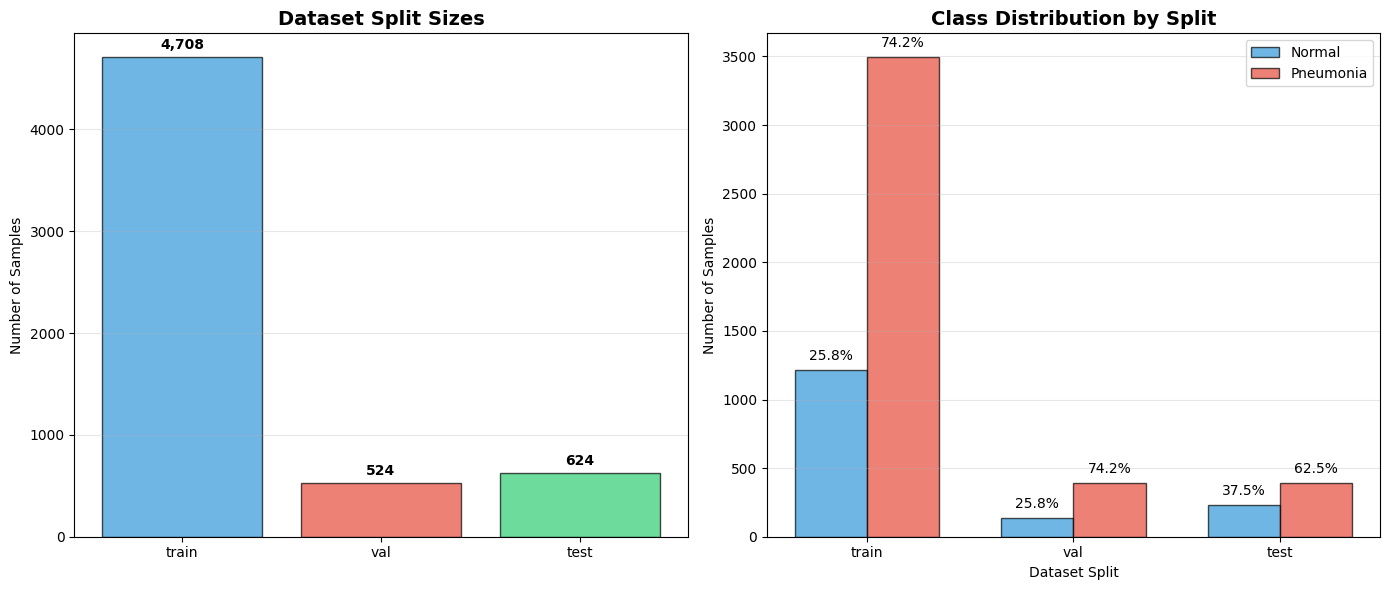

In [8]:
# Analyze dataset distribution for class imbalance considerations
print("Analyzing dataset distribution...")
dataset_splits = explore_dataset_splits(train_loader, val_loader, test_loader)
print(f"\nDataset Summary: {dataset_splits}")

# Visualize dataset distribution
plot_dataset_distribution(dataset_splits)

> **_The impact of class imbalance_**
> 
> Medical datasets often have class imbalance. This affects optimization because:
> 
> - Models may focus compute on majority class features
> - Batch composition affects memory usage patterns
> - Some optimization techniques (like pruning) may disproportionately affect minority class performance

Sample chest X-ray images:


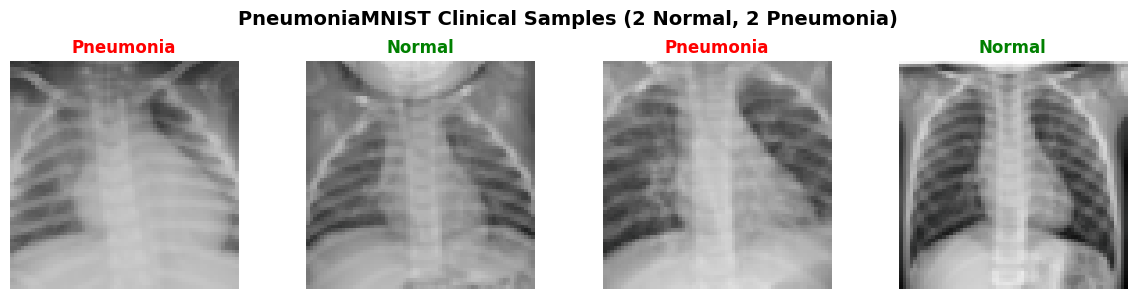

Displayed 4 images: 2 normal, 2 pneumonia


In [9]:
# Visualize sample images to understand data characteristics
print("Sample chest X-ray images:")
visualize_sample_images(train_loader, num_samples=4)

## Step 3: Create and analyze the baseline model
We will use [ResNet-18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) as our baseline - a popular choice for medical imaging that balances accuracy and efficiency.

The original model structure is architected for ImageNet (1000 classes), so we modify the model with a custom head to support our new classification task.

In [10]:
# Create the baseline ResNet-18 model
print("Creating ResNet-18 baseline model...")

baseline_model = create_baseline_model(
    num_classes=CONFIG['num_classes'], 
    input_size=CONFIG['image_size'], 
    pretrained=False  # Training from scratch for fair optimization comparison
)
baseline_model = baseline_model.to(device)

print(f"Baseline model created and deployed to {device}")
print(f"   Architecture: {baseline_model.architecture_name}")

Creating ResNet-18 baseline model...
Baseline model created and deployed to cuda
   Architecture: ResNet-18-Adaptive


In [11]:
# Get model information
model_info = get_model_info(baseline_model)

print(f"\nModel Information:")
print(f"   Architecture: {model_info['architecture']}")
print(f"   Total Parameters: {model_info['total_parameters']:,}")
print(f"   Model Size: {model_info['model_size_mb']:.1f} MB")
print(f"   Input Size: {model_info['input_size']}x{model_info['input_size']}")

# Analyze layer composition 
layer_breakdown = model_info['layer_breakdown']
print(f"\nLayer Composition:")
print(f"   Convolution Layers: {layer_breakdown['conv_layers']['count']} ({layer_breakdown['conv_layers']['total_params']:,} params)")
print(f"   Linear Layers: {layer_breakdown['linear_layers']['count']} ({layer_breakdown['linear_layers']['total_params']:,} params)")
print(f"   Normalization Layers: {layer_breakdown['norm_layers']['count']}")
print(f"   Activation Types: {', '.join(layer_breakdown['activation_layers']['types'])}")

# Get parameter distribution
if 'parameter_distribution' in layer_breakdown:
    param_dist = layer_breakdown['parameter_distribution']
    print(f"\nParameter Distribution:")
    print(f"   Convolution: {param_dist['conv_percentage']:.2f}%")
    print(f"   Linear: {param_dist['linear_percentage']:.2f}%")


Model Information:
   Architecture: ResNet-18-Adaptive
   Total Parameters: 11,177,538
   Model Size: 42.6 MB
   Input Size: 64x64

Layer Composition:
   Convolution Layers: 20 (11,166,912 params)
   Linear Layers: 1 (1,026 params)
   Normalization Layers: 20
   Activation Types: ReLU

Parameter Distribution:
   Convolution: 99.99%
   Linear: 0.01%


In [12]:
# Display the model architecture
summary(baseline_model, input_size=(3, CONFIG["image_size"], CONFIG["image_size"]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [13]:
baseline_model

ResNetBaseline(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

> **_Brainstorming time: Optimizations by layer type_**
> 
> Try to remember from the course, which architectural optimizations most benefit each layer type? Looking at the layer composition, our model is convolution-heavy - this is your starting point!

## Step 4: Train and evaluate baseline model
Now, we define the baseline model and evaluate its performance on key accuracy metrics - all future optimizations should maintain a similar clinical performance standard.

Establishing robust baseline metrics is crucial for medical AI. Any optimization must preserve clinical safety while improving computational efficiency.

In [14]:
os.makedirs("../results", exist_ok=True)

Starting baseline model training for pneumonia detection...
   Config: 10 epochs, lr=0.0003, wd=0.0001


Epoch 1/10 [Train]:   0%|                                                   | 0/148 [00:00<?, ?it/s]

   Epoch  1: Train Acc  92.4% | Val Acc  29.8% | Train Loss 0.2016 | Val Loss 12.0479 | LR 0.000300
      New best model saved (Val Acc: 29.8%)


   Epoch  2: Train Acc  95.5% | Val Acc  86.6% | Train Loss 0.1251 | Val Loss 0.3416 | LR 0.000300
      New best model saved (Val Acc: 86.6%)


   Epoch  3: Train Acc  96.1% | Val Acc  94.8% | Train Loss 0.1151 | Val Loss 0.1230 | LR 0.000300
      New best model saved (Val Acc: 94.8%)


...

   Epoch  6: Train Acc  98.7% | Val Acc  97.1% | Train Loss 0.0364 | Val Loss 0.0803 | LR 0.000030


   Epoch  7: Train Acc  99.2% | Val Acc  97.7% | Train Loss 0.0291 | Val Loss 0.0720 | LR 0.000003
      New best model saved (Val Acc: 97.7%)


   Epoch  8: Train Acc  99.2% | Val Acc  97.9% | Train Loss 0.0224 | Val Loss 0.0709 | LR 0.000003
      New best model saved (Val Acc: 97.9%)


   Epoch  9: Train Acc  99.2% | Val Acc  97.7% | Train Loss 0.0211 | Val Loss 0.0678 | LR 0.000003


   Epoch 10: Train Acc  99.1% | Val Acc  97.7% | Train Loss 0.0243 | Val Loss 0.0686 | LR 0.000000
Training completed! Best validation accuracy: 97.90%


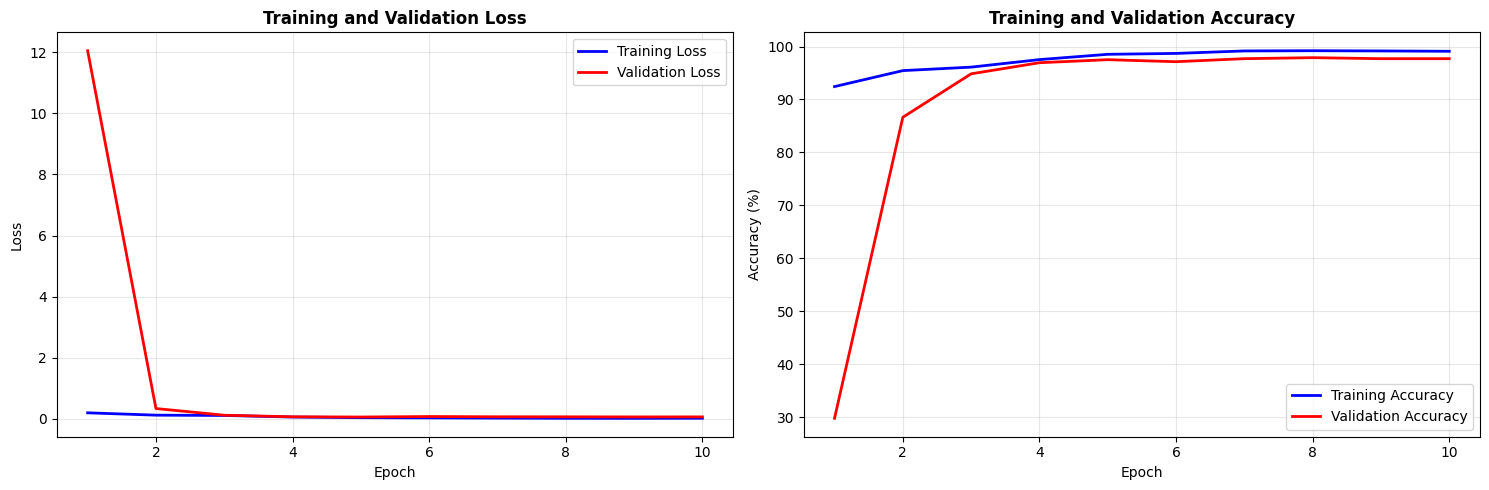


Training Summary:
   Best Validation Accuracy: 97.9%
   Total Epochs: 10
   Final Training Accuracy: 99.1%
   Final Validation Accuracy: 97.7%


In [15]:
# Training configuration
TRAINING_CONFIG = {
    'num_epochs': 10,           # Sufficient for convergence analysis
    'learning_rate': 0.0003,    # Conservative rate for stable training
    'lr_step_size': 3,          # Learning rate decay schedule
    'weight_decay': 1e-4,       # Regularization for generalization
    'patience': 3               # Early stopping for efficiency
}

# Train the model
baseline_model, training_history = train_baseline_model(
    baseline_model, train_loader, val_loader, device, TRAINING_CONFIG
)

# Plot training curves with analysis
plot_training_history(training_history)

> **Training insights: What does the training history tell us?**
> 
> The initial low validation accuracy is due to extreme overfitting due to the small dataset size in comparison to the model's parameter size. The presence of early plateaus and fast convergence also highlight that the architecture has high representational power - we can likely apply aggressive optimization without accuracy degradation.

In [16]:
# Evaluate model performance with multiple thresholds 
print(f"Running eval benchmark on {dataset_splits['test']['total']} test samples ...")
eval_results = evaluate_with_multiple_thresholds(baseline_model, test_loader, device, [0.4, 0.7])

Running eval benchmark on 624 test samples ...

Evaluating with threshold 0.4:


Clinical Evaluation Results (threshold: 0.400):
   Accuracy:  86.5%
   Precision: 82.4% (PPV - Positive Predictive Value)
   Recall:    99.7% (Sensitivity)
   F1 Score:  90.3%
   AUC-ROC:   0.965

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     151
   False Positives (Normal misclassified):            83
   False Negatives (Pneumonia missed):                 1
   True Positives (Pneumonia correctly detected):   389

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     99.7% (detects 99.7% of pneumonia cases)
   Specificity (True Negative Rate):     64.5% (correctly identifies 64.5% of normal cases)
   PPV (Positive Predictive Value):      82.4% (when model predicts pneumonia, it's correct 82.4% of time)
   NPV (Negative Predictive Value):      99.3% (when model predicts normal, it's correct 99.3% of time)

Clinical Significance:
   False Negative Rate: 0.3% (missed pneumonia cases - critical for patient safety)
   False Positive 

> **Clinical threshold selection**
>
> Different thresholds optimize for different clinical scenarios. Lower thresholds (0.4) maximize sensitivity for screening, while higher thresholds (0.7) balance precision and recall for diagnostic confirmation.

## Step 5: Profile baseline model for latency, throughput, and memory usage

Comprehensive performance profiling forms the foundation of our optimization strategy. We will measure all key metrics that impact multi-tenant deployment.

In [17]:
# Initialize performance profiler
profiler = PerformanceProfiler(device=str(device))
print(f"Performance profiler initialized for {device}")

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(val_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"\nSample batch for profiling:")
print(f"   Batch shape: {sample_images.shape}")
print(f"   Memory usage: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")

Performance profiler initialized for cuda

Sample batch for profiling:
   Batch shape: torch.Size([32, 3, 64, 64])
   Memory usage: 1.5 MB


In [18]:
# Profile inference timing
print("Profiling inference timing...")

timing_results = profiler.profile_inference_time(
    model=baseline_model,
    input_tensor=sample_images,
    num_runs=100,       # Sufficient for statistical significance
    warmup_runs=10      # GPU warmup for consistent measurements
)

print(f"\nTiming Results:")
print(f"   Single Sample Latency: {timing_results['single_sample_ms']:.2f} ms")
print(f"   (Single) Batch Throughput: {timing_results['throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Batch Latency: {timing_results['batch_total_ms']:.2f} ms")
print(f"   Batch Throughput: {timing_results['batch_throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Mean Inference Time: {timing_results['mean_ms']:.2f} ms")
print(f"   95th Percentile: {timing_results['p95_ms']:.2f} ms")
print(f"   Standard Deviation: {timing_results['std_ms']:.2f} ms")

Profiling inference timing...



Timing Results:
   Single Sample Latency: 3.53 ms
   (Single) Batch Throughput: 283.4 samples/sec
   Batch Latency: 25.14 ms
   Batch Throughput: 1272.6 samples/sec
   Mean Inference Time: 3.53 ms
   95th Percentile: 4.15 ms
   Standard Deviation: 0.40 ms


> **Latency vs throughput trade-offs**
>
> Single sample latency measures real-time diagnostic speed, while batch throughput indicates multi-tenant efficiency. Both metrics are crucial for different deployment scenarios.

In [19]:
# Profile FLOPs for computational efficiency analysis
flops_results = profiler.profile_flops(
    model=baseline_model, 
    input_tensor=sample_images
)

if 'error' in flops_results:
    print(f"FLOPs calculation failed: {flops_results['error']}")
else:
    print(f"\nFLOPs Results:")
    print(f"   Total: {flops_results['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {flops_results['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in flops_results and flops_results['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(flops_results['module_percentage'].items())[:5]:
            gflops = flops_results['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 58.21 GFLOPs
   Per Sample: 1.82 GFLOPs

   Top Operations (by FLOPs):
     conv: 99.7% (58.03 GFLOPs)
     batch_norm: 0.3% (0.16 GFLOPs)
     upsample_bilinear2d: 0.0% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [20]:
# Profile GPU memory usage
print("Profiling GPU memory usage...")

memory_results = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=sample_images
)

if 'error' not in memory_results:
    print(f"\nMemory Results:")
    print(f"   Peak GPU Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {memory_results['memory_increase_mb']:.1f} MB")
    
    # Component breakdown
    if 'component_breakdown' in memory_results:
        components = memory_results['component_breakdown']
        print(f"\nMemory Component Breakdown:")
        for component, usage in components.items():
            print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    print(f"WARNING: Memory profiling error: {memory_results['error']}")
    memory_results = {}

Profiling GPU memory usage...

Memory Results:
   Peak GPU Memory: 330.5 MB
   Memory Increase: 227.2 MB

Memory Component Breakdown:
   Model Parameters Mb: 42.6 MB
   Input Tensor Mb: 1.5 MB
   Output Tensor Mb: 0.0 MB
   Activations Mb: 225.7 MB


> **_Did you notice? A major optimization opportunity hiding in plain sight!_**
> 
> Look carefully at the model summary above. Something doesn't add up with our input/output dimensions...
> 
> Compare the input size we are feeding (64x64) with the first convolution layer's output size. The first Conv2d layer shows output `[-1, 64, 112, 112]` but our input is only 64x64. Where are those extra pixels coming from? Complete the TODO below to find out.
> 
> *Optimization opportunity:* This might be your biggest single optimization win, in both speed and memory usage! Keep this insight in mind as you analyze the profiling results below.

In [21]:
print(inspect.getsource(baseline_model.forward))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with adaptive input interpolation for variable input sizes.
        
        Automatically handles input size adaptation to leverage ImageNet pretrained
        features optimally. Critical for medical imaging where input sizes may vary
        across different acquisition protocols.
        
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes) for classification
            
        Note:
            Bilinear interpolation maintains spatial relationships in medical images
            while adapting to the expected ImageNet input size for optimal
            pretrained feature utilization.
            
        Example:
            >>> model = ResNetBaseline()
            >>> input_tensor = torch.randn(8, 3, 28, 28)  # Variable input size
            >>> output = model(input

In [22]:
# Inspect the baseline model's forward method using `inspect.get_source()`
print("Manually inspect the ResNetBaseline forward method:")
baseline_model_forward = inspect.getsource(baseline_model.forward) # TODO: Add your code here
print(baseline_model_forward)

print("\nDiscussion questions:")
print("1. What happens when height != self.target_size? What is self.target_size set to?") 
print("2. How much computational and memory overhead does F.interpolate add? (Hint: Compare 64x64 vs 224x224 pixel counts)")
print("3. Is this interpolation necessary for pneumonia detection, or just a legacy from ImageNet pretraining?")

Manually inspect the ResNetBaseline forward method:
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with adaptive input interpolation for variable input sizes.
        
        Automatically handles input size adaptation to leverage ImageNet pretrained
        features optimally. Critical for medical imaging where input sizes may vary
        across different acquisition protocols.
        
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes) for classification
            
        Note:
            Bilinear interpolation maintains spatial relationships in medical images
            while adapting to the expected ImageNet input size for optimal
            pretrained feature utilization.
            
        Example:
            >>> model = ResNetBaseline()
            >>> input_tensor = torch.randn(8, 3, 28, 28)  # Vari

In [23]:
# Detailed PyTorch profiler
print("Running detailed PyTorch profiler...")

detailed_results = profiler.profile_with_pytorch_profiler(
    model=baseline_model,
    input_tensor=sample_images,
    num_steps=10        # Sufficient for operation breakdown analysis
)

if 'error' not in detailed_results:
    print(f"\nOperation Breakdown:")
    op_breakdown = detailed_results['operation_breakdown']
    
    # Show top operations for optimization targeting
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1:  # Only show operations > 1%
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
else:
    print(f"WARNING: Detailed profiling error: {detailed_results['error']}")
    detailed_results = {}

Running detailed PyTorch profiler...



Operation Breakdown:
   Convolution Ops: 45.6%
   Normalization Ops: 29.7%
   Other Ops: 15.3%
   Activation Ops: 4.4%
   Matrix Multiply Ops: 3.5%
   Pooling Ops: 1.2%


## Step 6: Visualize and save baseline model's performance

Comprehensive visualization helps understand optimization opportunities and track progress across optimization experiments.

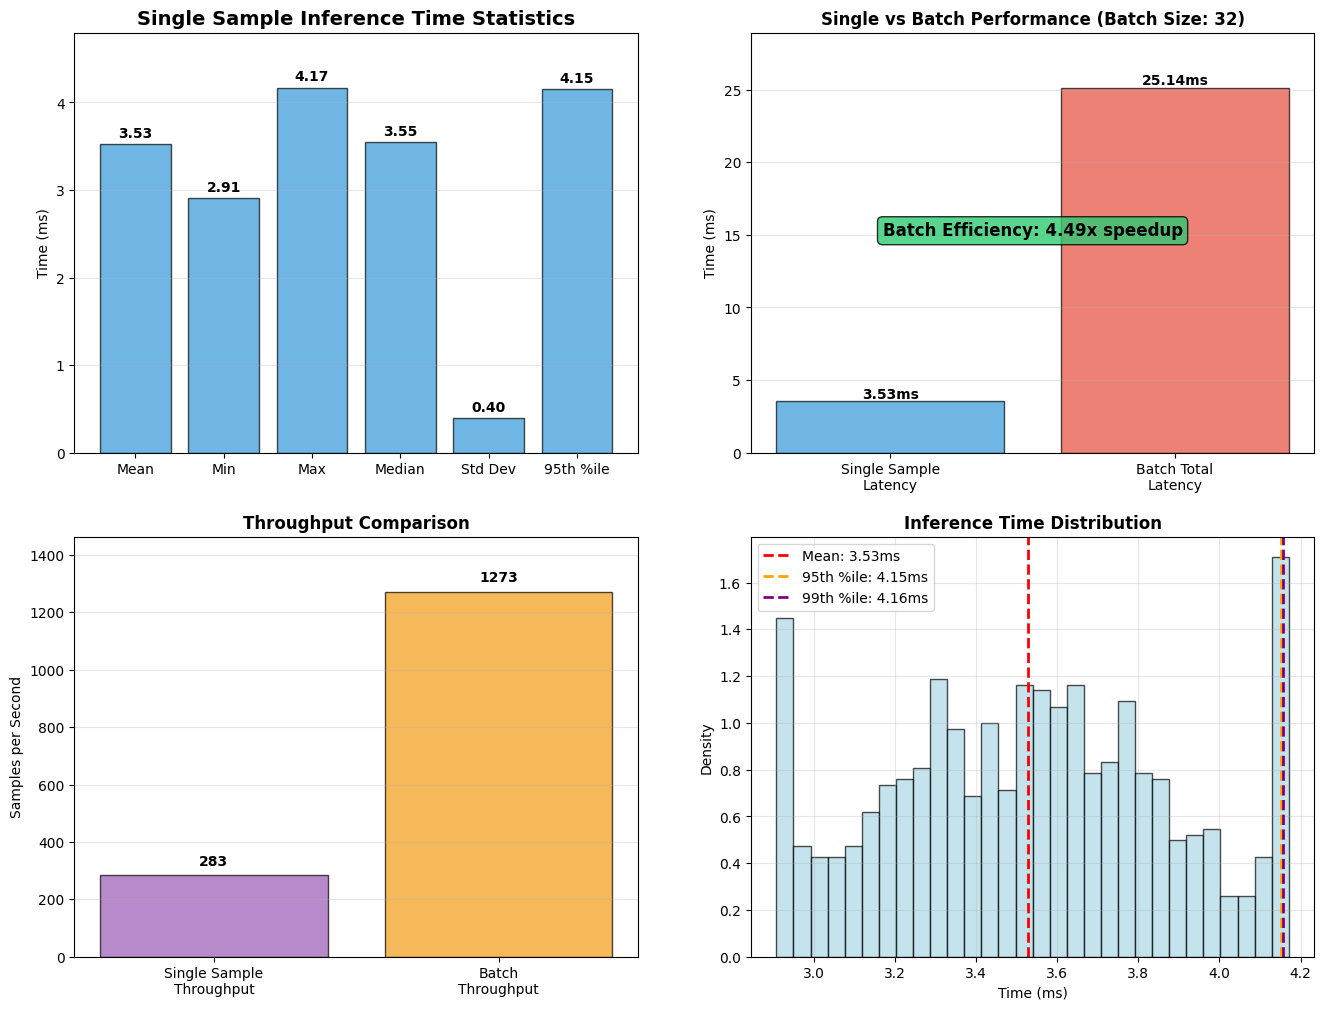

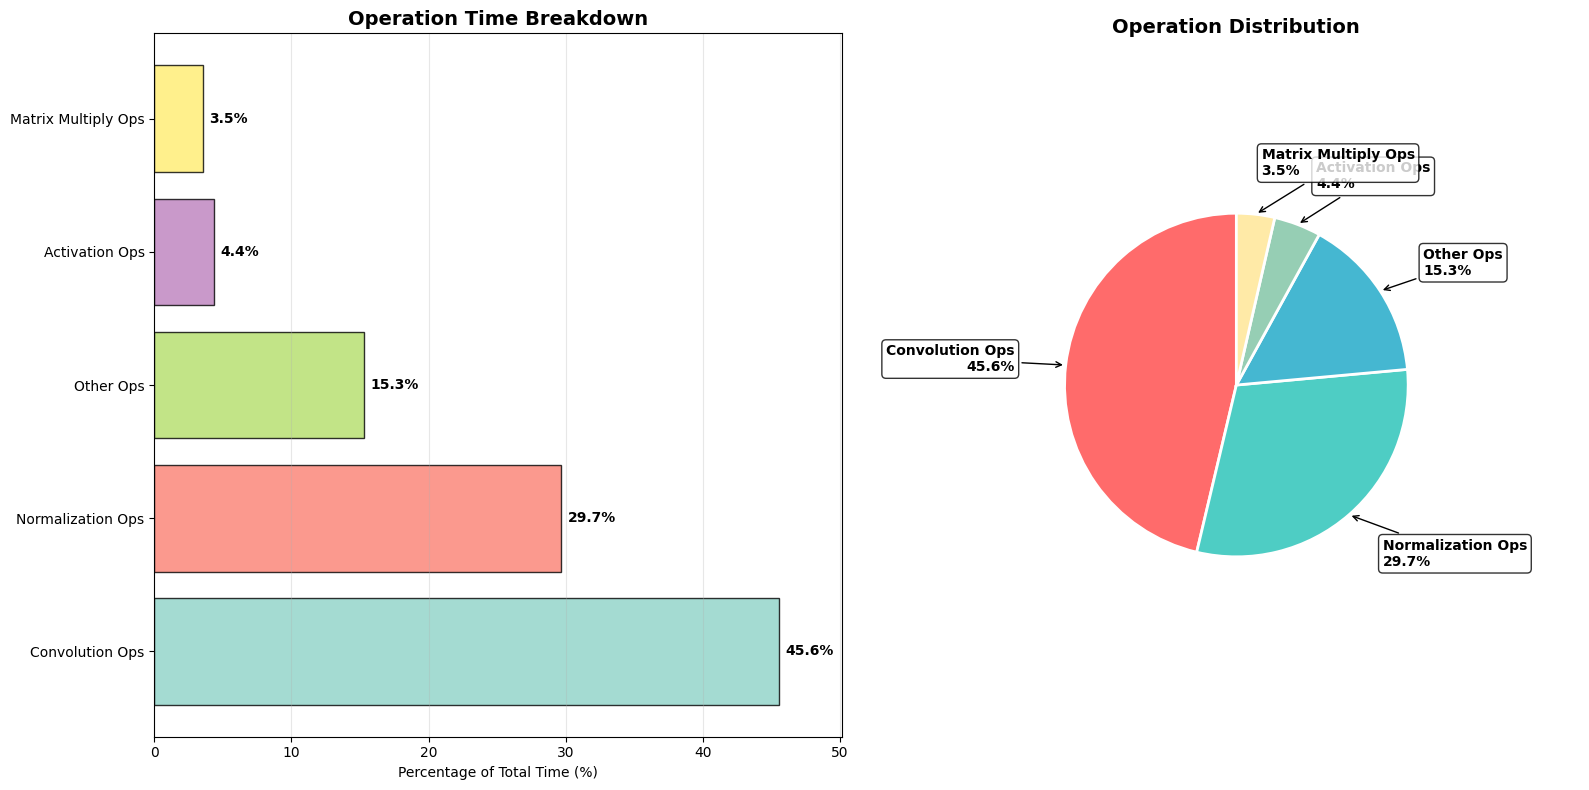

In [24]:
# Visualize performance profile
plot_performance_profile(timing_results)

# Visualize operation breakdown
if detailed_results and 'operation_breakdown' in detailed_results:
    plot_operation_breakdown(detailed_results['operation_breakdown'])
else:
    print("WARNING: Operation breakdown visualization not available")

In [25]:
# Compile baseline results for optimization notebooks
baseline_results = {
    'model_name': 'ResNet-18 Baseline',
    'architecture': model_info['architecture'],
    'total_parameters': model_info['total_parameters'],
    'model_size_mb': model_info['model_size_mb'],
    'config': CONFIG,
    'eval_results': eval_results,
    'timing': timing_results,
    'flops': flops_results,
    'memory': memory_results,
    'operation_breakdown': detailed_results['operation_breakdown'],
    'model_info': model_info,
    'dataset_info': dataset_info,
    'parameter_breakdown': count_parameters_by_type(baseline_model)
}

# Save baseline results
with open('../results/baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Baseline results saved to 'baseline_results.pkl' in the `results/` folder")
print("   This will be used for comparison in optimization notebooks.")

Baseline results saved to 'baseline_results.pkl' in the `results/` folder
   This will be used for comparison in optimization notebooks.


In [26]:
baseline_results

{'model_name': 'ResNet-18 Baseline',
 'architecture': 'ResNet-18-Adaptive',
 'total_parameters': 11177538,
 'model_size_mb': 42.63892364501953,
 'config': {'image_size': 64,
  'num_classes': 2,
  'batch_size': 32,
  'subset_size': None},
 'eval_results': {0.4: {'accuracy': 0.8653846383094788,
   'precision': 0.8241525292396545,
   'recall': 0.9974358677864075,
   'f1': 0.9025521874427795,
   'auc': 0.965001106262207,
   'confusion_matrix': array([[151,  83],
          [  1, 389]]),
   'threshold': 0.4},
  0.7: {'accuracy': 0.8910256624221802,
   'precision': 0.8530701994895935,
   'recall': 0.9974358677864075,
   'f1': 0.9196217656135559,
   'auc': 0.965001106262207,
   'confusion_matrix': array([[167,  67],
          [  1, 389]]),
   'threshold': 0.7}},
 'timing': {'mean_ms': 3.529098749277182,
  'std_ms': 0.39703660343715697,
  'min_ms': 2.9081989778205752,
  'max_ms': 4.170822037849575,
  'median_ms': 3.5518495133146644,
  'p95_ms': 4.152857774170116,
  'p99_ms': 4.157622321508825,


> **Brainstorming time!**
> 
> Based on your profiling results above, analyze the following:
> 
> 1. **Primary bottleneck**: What is the main performance bottleneck - compute time, memory usage, or data transfer?

memory usage is the main performance bottleneck
> 
> 2. **Operation analysis**: Which types of operations (convolution, linear, activation) consume the most time? What percentage?
> 

convolutions consume most time - approx 45.55%

> 3. **Memory patterns**: How much memory does the model use during inference? What contributes most to memory usage?
> 

330 mb. Activations contribute most to memory usage

> 4. **Optimization priority**: Based on the profiling data, which optimization techniques would you prioritize:

>    - Architecture modifications (channel reduction, efficient blocks) --> remove interpolation, efficient blocks
>    - Precision optimization (mixed precision, quantization) --> mixed precision when deploying model to target device(while converting to onnx format)
>    - Hardware acceleration (TensorRT for GPU, ...)--> for now ONNX is expected to help achieve our target optimization stats
>   
>    _IMPORTANT:_ Did you discover the major inefficiency we hinted at earlier? How much improvement could removing the 64→224 interpolation provide?

approximately 92% reduction in flops 

---

## Step 7: Analyze optimization opportunities

Now that we have established the baseline performance, it's time for you to conduct a deeper analysis that will guide the optimization strategy. This section contains **two focused analysis checkpoints**:

1. **Architecture optimization analysis** - Identify specific opportunities in the ResNet-18 architecture
2. **Deployment optimization analysis** - Understand hardware acceleration and deployment strategies

Complete these analysis checkpoints to develop your optimization roadmap!

### Analysis checkpoint 1: Architecture optimization opportunities

**Task:** Analyze the ResNet-18 architecture to identify the **top 2 optimization opportunities** from the techniques covered in the course. Available techniques to consider include:
- Grouped convolutions
- Depth-wise separable convolutions
- Inverted residuals with linear bottlenecks
- Low-rank factorization
- Channel organization strategies _(NOTE: this is a hybrid optimization between architecture and hardware)_
- Parameter sharing / weight tying

Feel free to skip programmatic analysis of techniques which you deem to be non-applicable or less performant, but provide an explanation here or in the notebook's final markdown cell.

We will not be implementing following :

- Grouped convolutions  --> this adds more components and activations when compared with depthwise separable
- Low-rank factorization  --> There are no low rank factorization opportunities available for linear layer
- Channel organization strategies _(NOTE: this is a hybrid optimization between architecture and hardware)_ --> This is tricky and whether or not brings performance improvements depends on hardware.
- Parameter sharing / weight tying --> This is quite complex. we have better ways to achieve the targets.

**IMPORTANT:** Don't forget to also analyze the potential of interpolation removal from the model's forward method!

#### Recommended strategic analysis approach

Calculate the expected impact of applying each technique on parameter reduction programmatically to simplify follow-up analysis. Consider how parameter reduction / architectural improvements for each technique correlate with memory size (activation vs parameters), FLOPs, latency, throughput, and sensitivity to estimate optimization opportunity. HINTS are in each function's signature.

To populate the analysis dictionary with estimated optimiation opportunity, you can either:
1. Programmatically calculate optimization opportunity from parameter reduction and rule-of-thumb
2. Directly add the expected value in the analysis entries, and add a one-line explanation of the value selected as an in-line comment.

In [21]:
## Implement logic for each single technique analysis

def analyze_depthwise_separable_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze which convolution layers could benefit from depthwise separable convolutions/

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels (e.g., >=16)
    
    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for two layers now
    Speedup: Proportional to FLOP reduction, but can be penalized (e.g., ~0.6x) due to memory-access overhead, as many small operations may not fully utilize hardware parallelism
    Throughput: Directly scales with speedup estimates for batch processing scenarios
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Depthwise Separable Convolutions',
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        ##following 3 will require full model rebuild which is not feasible at this stage
        #'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        #'throughput_improvement_percent': 0,
        #'sensitivity_risk': ''
    }

    # TODO: Complete the analysis dictionary with relevant values
    
    model_name_module_tup_list = []
    dwp_params = []
    dwp_flops = []
    base_params = []
    base_flops = []
    height = 16 #sample_input_shape[1]
    width = 16 #sample_input_shape[2]
    
    for name, module in model.named_modules():
        
        if isinstance(module, nn.Conv2d) and module.kernel_size[0] > 1 and module.in_channels >= 16:
            model_name_module_tup_list.append((name, module))
    analysis['candidate_layers'] = [module for _, module in model_name_module_tup_list]
    analysis['total_candidates'] = len(analysis['candidate_layers'])
    for name, module in model_name_module_tup_list:

        std_params = module.out_channels * module.in_channels * (module.kernel_size[0] * module.kernel_size[1])
        std_flops = std_params * height * width
        base_params.append(std_params)
        base_flops.append(std_flops)
        
        # Depthwise separable convolution
        # Depthwise: each input channel gets its own 3x3 filter
        dw_params = module.in_channels * (module.kernel_size[0] * module.kernel_size[1])
        dw_flops = dw_params * height * width
        if module.stride[0] == 2:
            height = height//2
            width = width//2
        
        # Pointwise: 1x1 convolution to combine channels
        pw_params = module.in_channels * module.out_channels * 1 * 1
        pw_flops = pw_params * height * width
    
        total_params = dw_params + pw_params
        total_flops = dw_flops + pw_flops
        dwp_params.append(total_params)
        dwp_flops.append(total_flops)

    conv_base_params = sum(base_params)
    conv_base_flops = sum(base_flops)
    conv_dwp_params = sum(dwp_params)
    conv_dwp_flops = sum(dwp_flops)
    avg_param_reduction = ((conv_base_params - conv_dwp_params) / conv_base_params) * 100
    avg_flop_reduction = ((conv_base_flops -  conv_dwp_flops) /  conv_base_flops) * 100
    analysis['avg_flop_reduction_percent'] = avg_flop_reduction
    analysis['avg_param_reduction_percent'] = avg_param_reduction
    final_speedup = avg_flop_reduction * 0.6
    analysis['estimated_speedup'] = final_speedup
    model_params = sum([p.numel() for p in model.parameters()])
    params_cand_layers = sum([p.numel() for module in analysis['candidate_layers'] for p in module.parameters()])
    params_non_cand_layers = model_params - params_cand_layers

    params_dwp_model = conv_dwp_params + params_non_cand_layers
    model_param_reduction = model_params - params_dwp_model
    model_mem_reduction = (model_param_reduction * 4)/(1024**2)
    analysis['estimated_memory_reduction_mb'] = model_mem_reduction
    # HINT: 
    # 1. Find candidates: for name, module in model.named_modules() if isinstance(module, nn.Conv2d) and module.kernel_size[0] > 1 and module.in_channels >= 16
    # 2. Calculate per-layer: separable_params = (in_ch * k²) + (in_ch * out_ch), separable_flops = (feature_size * in_ch * k²) + (feature_size * in_ch * out_ch)
    # 3. Aggregate impact: avg_flop_reduction = total_flops_saved / total_candidate_flops, then apply hardware penalty: final_speedup = theoretical_speedup * 0.6    
    return analysis

def analyze_inverted_residuals_potential(model):
    """
    TODO: Analyze potential for inverted residual blocks (expand -> depthwise -> project).
    Hint: Look for 3x3 convolutions that expand channels (MobileNet-style patterns)
    
    Memory impact: Can reduce average memory but may increase peak during expansion phase
    FLOP improvements: Layer-specific FLOP savings through efficient bottleneck patterns
    Speedup: 1.1x to 1.2x based on candidate count and architecture structure (variable)
    Throughput: Modest improvements proportional to architectural efficiency gains
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Inverted Residual Blocks',
        #'residual_candidates': [], #This requires looking into model implementation, cannot be done programmatically
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        #'estimated_speedup': 1.0, #cannot be estimated from given hint logic
        'estimated_memory_reduction_mb': 0,
        'avg_param_reduction_percent': 0,
        #'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        #'throughput_improvement_percent': 0,
        #'sensitivity_risk': ''
    }
    base_params = []
    base_flops = []
    mod_list = {}
    dwp_params = []
    dwp_flops = []
    kernel_size = 3
    height = 16 #sample_input_shape[1]
    width = 16 #sample_input_shape[2]

    for name, module in model.named_modules():
        if hasattr(module, 'children') and len([m for m in module.children() if isinstance(m, nn.Conv2d)]) >= 2:
            ##append module in dict
            mod_list[name] = [m for m in module.children() if isinstance(m, nn.Conv2d)]
            in_channels = mod_list[name][0].in_channels
            out_channels = mod_list[name][-1].out_channels
            std_params = sum([p.numel() for p in module.parameters()])
            base_params.append(std_params)
            std_flops = std_params * height * width
            base_flops.append(std_flops)

            if ((mod_list[name][0].stride[0] == 2) or (mod_list[name][-1].stride[0] == 2)):
                width = width/2
                height = height/2

            expand_ratio = 2

            pw_1_params = in_channels * in_channels * expand_ratio * 1 * 1
            pw_1_flops = pw_1_params * height * width

            dw_params = in_channels * expand_ratio * (kernel_size**2)
            dw_flops = dw_params * height * width  

            pw_2_params = in_channels * expand_ratio * out_channels * 1 * 1
            pw_2_flops = pw_2_params * height * width
        
            total_params = pw_1_params + dw_params + pw_2_params
            total_flops = pw_1_flops + dw_flops + pw_2_flops
            dwp_params.append(total_params)
            dwp_flops.append(total_flops)
    analysis['total_candidates'] = len(mod_list)
    conv_base_params = sum(base_params)
    conv_base_flops = sum(base_flops)
    conv_dwp_params = sum(dwp_params)
    conv_dwp_flops = sum(dwp_flops)
    avg_param_reduction = ((conv_base_params - conv_dwp_params) / (conv_base_params+1)) * 100 
    avg_flop_reduction = ((conv_base_flops -  conv_dwp_flops) /  (conv_base_flops+1)) * 100
    analysis['avg_flop_reduction_percent'] = avg_flop_reduction
    analysis['avg_param_reduction_percent'] = avg_param_reduction

    model_params = sum([p.numel() for p in model.parameters()])
    model_hypothetical = nn.Sequential(nn.ModuleList(mod for l in mod_list.values() for mod in l))
    params_cand_layers = sum([p.numel() for p in model_hypothetical.parameters()])
    params_non_cand_layers = model_params - params_cand_layers

    params_dwp_model = conv_dwp_params + params_non_cand_layers
    model_param_reduction = model_params - params_dwp_model
    model_mem_reduction = (model_param_reduction * 4)/(1024**2)
    analysis['estimated_memory_reduction_mb'] = model_mem_reduction
    
    #Below logic is incorrect, so we will not calculate speedup here
    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find candidates: for name, module in model.named_modules() if hasattr(module, 'children') and len([m for m in module.children() if isinstance(m, nn.Conv2d)]) >= 3
    # 2. Calculate per-layer: Use rule-of-thumb flop_reduction_percent = 60 for inverted residual patterns (expand->depthwise->project)
    # 3. Aggregate impact: coverage_factor = min(1.0, total_candidates / 8), then speedup = 1.0 + (avg_reduction / 100) * conv_impact * 2.5
    
    return analysis

def analyze_interpolation_removal_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze the potential for removing interpolation overhead by processing images at native resolution.
    HINT: This is the biggest single optimization opportunity! Focus on calculating the computational overhead from 64x64→224x224 interpolation
    
    Memory impact: A % of activtion memory scales with input size reduction (12x theoretical)
    FLOP improvements: Direct 12x reduction in convolution operations
    Speedup: LIMITED by Amdahl's law - a % of the convolution_ops scales with input size, but there are also fixed overheads (FC layers, data loading) that don't scale with input size
    Throughput: Better for batch processing where fixed costs are amortized (make sure to multiply estimate by at least the current batch processing)
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Interpolation Removal (Native Resolution)',
        'interpolation_size': 224,  # TODO: Find this integer value in the model's forward() method 
        'original_image_size': CONFIG["image_size"],
        'avg_flop_reduction_percent': 0,
        #'estimated_speedup': 1.0, # we will not implement this as there are too many moving components which are difficult to calculate
        'estimated_memory_reduction_mb': 0, #no change in parameters
        #'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        #'throughput_improvement_percent': 0,
        #'sensitivity_risk': ''
    }
    analysis['interpolation_size'] = 224
    interpolation_factor = (analysis['interpolation_size'] / 64) ** 2
    analysis['avg_flop_reduction_percent'] = 1.0 - (1.0 / interpolation_factor)
    
    # TODO: Complete the analysis dictionary with relevant values
    # HINT:
    # 1. Find overhead: Look for interpolation_size = 224 in model.forward(), calculate interpolation_factor = (224 / 64)² = 12.25x
    # 2. Calculate theoretical: theoretical_flop_reduction = 1.0 - (1.0 / interpolation_factor) = ~91.8%
    # 3. Apply Amdahl's Law: Only scalable_portion = conv_coverage * 0.6 benefits, speedup = 1 / (fixed_portion + scalable_portion / interpolation_factor)

    return analysis

In [22]:
# Run the complete architecture optimization analysis with all 5 implemented analysis functions above
def run_architecture_optimization_analysis(model):
    """
    Main function to run all architecture optimization analyses.
    """
    print("Running architecture optimization analysis...")
    
    # Call each analysis function
    depthwise_analysis = analyze_depthwise_separable_potential(model)
    inverted_analysis = analyze_inverted_residuals_potential(model)
    interpolation_analysis = analyze_interpolation_removal_potential(model)
    
    # Combine all analyses into comprehensive result
    # TODO: Remove any techniques which haven't been analyzed
    optimization_techniques = {
        'depthwise_separable': {
            'candidate_layers': depthwise_analysis['total_candidates'],
            'avg_param_reduction_percent': depthwise_analysis['avg_param_reduction_percent'],
            'estimated_speedup': depthwise_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': depthwise_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': depthwise_analysis['estimated_memory_reduction_mb'],
            'details': depthwise_analysis['candidate_layers'][:3]  # Show top 3
        },
        'inverted_residuals': {
            'expansion_candidates': inverted_analysis['total_candidates'],
            'avg_flop_reduction_percent': inverted_analysis['avg_flop_reduction_percent'],
            'avg_param_reduction_percent': inverted_analysis['avg_param_reduction_percent'],
            'estimated_memory_reduction_mb': inverted_analysis['estimated_memory_reduction_mb'],
        },
                
        'interpolation_removal': {
            'current_input_size': interpolation_analysis["interpolation_size"],
            'native_input_size': interpolation_analysis["original_image_size"],
            'avg_flop_reduction_percent': interpolation_analysis['avg_flop_reduction_percent'],
        }
    }
    
    return optimization_techniques

# Execute architecture analysis
arch_analysis = run_architecture_optimization_analysis(baseline_model)

# Display results
print(f"\nARCHITECTURE OPTIMIZATION RESULTS:")
for technique, details in arch_analysis.items():
    print(f"\n   {technique.replace('_', ' ').title()}:")
    for key, value in details.items():
        if key != 'details':
            print(f"     {key.replace('_', ' ').title()}: {value}")

Running architecture optimization analysis...

ARCHITECTURE OPTIMIZATION RESULTS:

   Depthwise Separable:
     Candidate Layers: 16
     Avg Param Reduction Percent: 88.61099459358688
     Estimated Speedup: 54.49904057017544
     Avg Flop Reduction Percent: 90.83173428362574
     Estimated Memory Reduction Mb: 37.133544921875

   Inverted Residuals:
     Expansion Candidates: 8
     Avg Flop Reduction Percent: 90.16213814240018
     Avg Param Reduction Percent: 82.52331853105814
     Estimated Memory Reduction Mb: 34.46142578125

   Interpolation Removal:
     Current Input Size: 224
     Native Input Size: 64
     Avg Flop Reduction Percent: 0.9183673469387755


> **_Before you move on...brainstorming time!_**
> 
> Based on your architecture analysis results, collect yours insights on architectural opportunities
> 
> 1. **Primary bottleneck**: What operation type consumes the most compute time in your model? Why does this pattern make sense for ResNet-18 architecture? How does this inform your optimization strategy?

Convolution consumes most of the compute time. ResNet-18 is computer vision classification model, so it makes sense to have lot of convolutions happening in there. All of these are dense convolution which means lot of conv operations plus model parameters in there which can be optimized.


> 2. **Resource trade-offs:**: Which optimizations reduce parameters vs which improve compute efficiency? How might accuracy be affected by each technique?

Depthwise Separable and Inverted Residual Blocks - both reduce parameters along with compute efficiency improvement. Interpolation removal will result in compute efficiency as there is no reduction in model parameters.
I do not think accuracy is going to be impacted much as there are lot of redundant parameters in resent-18 with respect to the datset size.


> 3. **Optimization priority**: In which order would you recommend implementing the 5 architectural techniques? Consider both impact and implementation difficulty.

1) Interpolation - This is easiest to implement
2) DepthWise Separable Convolution - This is next and has defined logic. Also parameter reduction, flop reduction and memory reduction is expected to be higher than inverted residual blocks
3) Inverted Residual Blocks - Though this might well be straightforward, size of expansion factor is going to hold key and this will need to be tuned.
Rest of the techniques we are not going to implement


> 4. **Feasibility assessment:**: Will the combined optimizations achieve the 3ms target? If not, what additional techniques might be needed?

We would not be able to assess it at this point of time. While interpolation removal is going to bring in reduction in peak memory, the other two techniques add more processing layers than in original model which is expected to increase latency and activation memory. In my opinion we should also try removing unneeded blocks from model altogether so long the clinical requirements are met. I think this will be required along with three optimization techniques that we are going to use.

### Analysis checkpoint 2: Deployment optimization opportunities

**Task:** Analyze deployment characteristics for our reference hardware, with a focus on batch processing trade-offs and mixed precision acceleration.

_Feel free to also add considerations from other hardware optimization techniques, such as leveraging specialized hardware acceleration units (e.g., Tensor Cores, NPUs) and other memory optimization patterns._

In [25]:
profiler = PerformanceProfiler(device=str(device))
print(f"Performance profiler initialized for {device}")

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(val_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)
sample_images.shape

Performance profiler initialized for cuda


torch.Size([32, 3, 64, 64])

In [26]:
# Detailed PyTorch profiler
print("Running detailed PyTorch profiler...")

detailed_results = profiler.profile_with_pytorch_profiler(
    model=baseline_model,
    input_tensor=sample_images,
    num_steps=10        # Sufficient for operation breakdown analysis
)

if 'error' not in detailed_results:
    print(f"\nOperation Breakdown:")
    op_breakdown = detailed_results['operation_breakdown']
    
    # Show top operations for optimization targeting
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1:  # Only show operations > 1%
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
else:
    print(f"WARNING: Detailed profiling error: {detailed_results['error']}")
    detailed_results = {}

Running detailed PyTorch profiler...

Operation Breakdown:
   Convolution Ops: 67.6%
   Other Ops: 16.0%
   Normalization Ops: 6.1%
   Matrix Multiply Ops: 3.8%
   Activation Ops: 3.7%
   Pooling Ops: 2.8%


In [27]:
detailed_results

{'operation_breakdown': {'matrix_multiply_ops': 3.8292480745419675,
  'other_ops': 15.978660628501059,
  'convolution_ops': 67.57832271719583,
  'normalization_ops': 6.096078553029965,
  'memory_ops': 0.052836611850834825,
  'activation_ops': 3.690373283982947,
  'pooling_ops': 2.774480130897387},
 'total_time_us': 1052134.080000002,
 'profiler_data': <torch.profiler.profiler.profile at 0x7f855199f7c0>}

In [29]:
detailed_results['operation_breakdown']['matrix_multiply_ops'], detailed_results['operation_breakdown']['convolution_ops']

(3.8292480745419675, 67.57832271719583)

In [30]:
# Profile GPU memory usage
print("Profiling GPU memory usage...")

memory_results = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=sample_images
)

if 'error' not in memory_results:
    print(f"\nMemory Results:")
    print(f"   Peak GPU Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {memory_results['memory_increase_mb']:.1f} MB")
    
    # Component breakdown
    if 'component_breakdown' in memory_results:
        components = memory_results['component_breakdown']
        print(f"\nMemory Component Breakdown:")
        for component, usage in components.items():
            print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    print(f"WARNING: Memory profiling error: {memory_results['error']}")
    memory_results = {}


Profiling GPU memory usage...

Memory Results:
   Peak GPU Memory: 280.0 MB
   Memory Increase: 227.2 MB

Memory Component Breakdown:
   Model Parameters Mb: 42.6 MB
   Input Tensor Mb: 1.5 MB
   Output Tensor Mb: 0.0 MB
   Activations Mb: 225.7 MB


In [31]:
memory_results

{'baseline_memory_mb': 52.81640625,
 'peak_memory_mb': 280.00390625,
 'current_memory_mb': 52.81689453125,
 'memory_increase_mb': 227.1875,
 'component_breakdown': {'model_parameters_mb': 42.63892364501953,
  'input_tensor_mb': 1.5,
  'output_tensor_mb': 0.000244140625,
  'activations_mb': 225.6875}}

In [32]:
# Profile inference timing
print("Profiling inference timing...")

timing_results = profiler.profile_inference_time(
    model=baseline_model,
    input_tensor=sample_images,
    num_runs=100,       # Sufficient for statistical significance
    warmup_runs=10      # GPU warmup for consistent measurements
)

print(f"\nTiming Results:")
print(f"   Single Sample Latency: {timing_results['single_sample_ms']:.2f} ms")
print(f"   (Single) Batch Throughput: {timing_results['throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Batch Latency: {timing_results['batch_total_ms']:.2f} ms")
print(f"   Batch Throughput: {timing_results['batch_throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Mean Inference Time: {timing_results['mean_ms']:.2f} ms")
print(f"   95th Percentile: {timing_results['p95_ms']:.2f} ms")
print(f"   Standard Deviation: {timing_results['std_ms']:.2f} ms")


Profiling inference timing...

Timing Results:
   Single Sample Latency: 3.86 ms
   (Single) Batch Throughput: 259.2 samples/sec
   Batch Latency: 25.01 ms
   Batch Throughput: 1279.5 samples/sec
   Mean Inference Time: 3.86 ms
   95th Percentile: 4.50 ms
   Standard Deviation: 0.40 ms


In [33]:
flops_results = profiler.profile_flops(
    model=baseline_model, 
    input_tensor=sample_images
)

if 'error' in flops_results:
    print(f"FLOPs calculation failed: {flops_results['error']}")
else:
    print(f"\nFLOPs Results:")
    print(f"   Total: {flops_results['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {flops_results['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in flops_results and flops_results['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(flops_results['module_percentage'].items())[:5]:
            gflops = flops_results['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")



Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 58.21 GFLOPs
   Per Sample: 1.82 GFLOPs

   Top Operations (by FLOPs):
     conv: 99.7% (58.03 GFLOPs)
     batch_norm: 0.3% (0.16 GFLOPs)
     upsample_bilinear2d: 0.0% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [73]:
### Implement logic for each single technique analysis 

def analyze_mixed_precision_potential(detailed_results):
    """    
    TODO: Analyze mixed precision (FP16) acceleration potential.
    HINTS: These are the key analysis points to focus on:
    - Mixed precision suitability calculation based on operation types (hardware accelerators for FP16 typically target matrix multiplies and convolutions)
    - Research-backed speedup estimates (1.8-2.5x for high coverage)
    - Memory reduction modeling (FP32->FP16 = ~50% reduction)
    - Throughput impact calculation (scales with speedup for batch processing scenarios)
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    analysis = {
        'technique': 'Mixed Precision (FP16)',
        'mixed_precision_eligible_ops': 0,
        'mixed_precision_coverage_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['batch_throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        #'sensitivity_risk': ''
    }

    eligible_ops = detailed_results['operation_breakdown']['matrix_multiply_ops'] + detailed_results['operation_breakdown']['convolution_ops'] 
    analysis['mixed_precision_eligible_ops'] = eligible_ops
    coverage_percent = (eligible_ops / 100) * 100
    analysis['mixed_precision_coverage_percent'] = coverage_percent
    estimated_speedup = 1.8 + (coverage_percent - 50) * 0.014 if coverage_percent > 50 else 0
    analysis['estimated_speedup'] = estimated_speedup
    analysis['estimated_memory_reduction_mb'] = memory_results['peak_memory_mb'] * 0.5 #(FP32->FP16)
    throughput = timing_results['batch_throughput_samples_per_sec'] * estimated_speedup
    analysis['throughput_improvement_percent'] = estimated_speedup
    analysis['avg_flop_reduction_percent'] = flops_results['module_breakdown_gflops']['conv'] * 0.5

    # TODO: Complete the analysis dictionary with relevant values
    # HINT: 3-step process
    # 1. Find mixed precision eligible ops: eligible_ops = matrix_ops + conv_ops from detailed_results['operation_breakdown']
    # 2. Calculate coverage: coverage_percent = (eligible_ops / total_ops) * 100, then research-backed speedup = 1.8 + (coverage - 50) * 0.014 if coverage > 50%
    # 3. Aggregate impact: memory_reduction = peak_memory_mb * 0.5 (FP32->FP16), throughput = baseline_throughput * estimated_speedup
    
    return analysis

def analyze_batch_processing_scenarios(model, mixed_precision_speedup, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    TODO: Analyze different deployment scenarios with realistic batch processing logic.
    
    HINT: Focus on finding optimal batch sizes for different use cases (real-time vs throughput) using the profiler.profile_multiple_batch_sizes() function.
    Real-time optimizes for lowest latency per sample, throughput optimizes for maximum samples/sec
    """
    # Initialize analysis structure (feel free to skip any entries you don't want to programmatically calculate)
    scenarios = {
        'real_time_diagnosis': {
            'optimal_batch_size': None,
            'current_latency_ms': None,
            'mixed_precision_latency_ms': None,
            'use_case': 'Emergency diagnosis, single patient processing'
        },
        'batch_processing': {
            'optimal_batch_size': None,
            'current_throughput_samples_sec': None,
            'mixed_precision_throughput_samples_sec': None,
            'use_case': 'Screening workflows, research processing'
        }
    }
    
    # Test batch sizes appropriate for T4 memory constraints
    batch_sizes = [1, 32, 64, 128]  # TODO: Add your values here

    print("   Profiling multiple batch sizes...")
    batch_results = profiler.profile_multiple_batch_sizes(
        model, sample_images.shape, batch_sizes
    )
    batches = list(batch_results.keys())
    sample_latency = []
    tps = []
    for batch in batches:
        sample_latency.append(result[batch]['timing']['single_sample_ms'])
        tps.append(result[batch]['timing']['throughput_samples_per_sec'])
    real_time_optimal = min(sample_latency)
    throughput_optimal = max(tps)
    optimal_batch_real_time = batches[sample_latency.index(real_time_optimal)]
    optimal_batch_tpt = batches[tps.index(throughput_optimal)]
    #print(result[optimal_batch_real_time])
    scenarios['real_time_diagnosis']['optimal_batch_size'] = result[optimal_batch_real_time]['timing']['batch_size']
    scenarios['real_time_diagnosis']['current_latency_ms'] = result[optimal_batch_real_time]['timing']['single_sample_ms']
    scenarios['real_time_diagnosis']['mixed_precision_latency_ms'] = result[optimal_batch_real_time]['timing']['single_sample_ms']/2
    
    scenarios['batch_processing']['optimal_batch_size'] = result[optimal_batch_tpt]['timing']['batch_size']
    scenarios['batch_processing']['current_throughput_samples_sec'] = result[optimal_batch_tpt]['timing']['throughput_samples_per_sec']
    scenarios['batch_processing']['mixed_precision_throughput_samples_sec'] = result[optimal_batch_tpt]['timing']['throughput_samples_per_sec']*2



    

    # TODO: Complete the analysis dictionary with relevant values
    # HINT: You can extract all information from batch_results 
    # 1. Find optimal configs: real_time_optimal = min(batches, key=lambda k: latency_per_sample), throughput_optimal = max(batches, key=lambda k: samples_per_sec)
    # 2. Create scenarios: Remember to apply mixed_precision_speedup to both latency (divide) and throughput (multiply) for deployment projections

    return batch_results, scenarios

Running Deployment Optimization Analysis...
   Profiling multiple batch sizes...


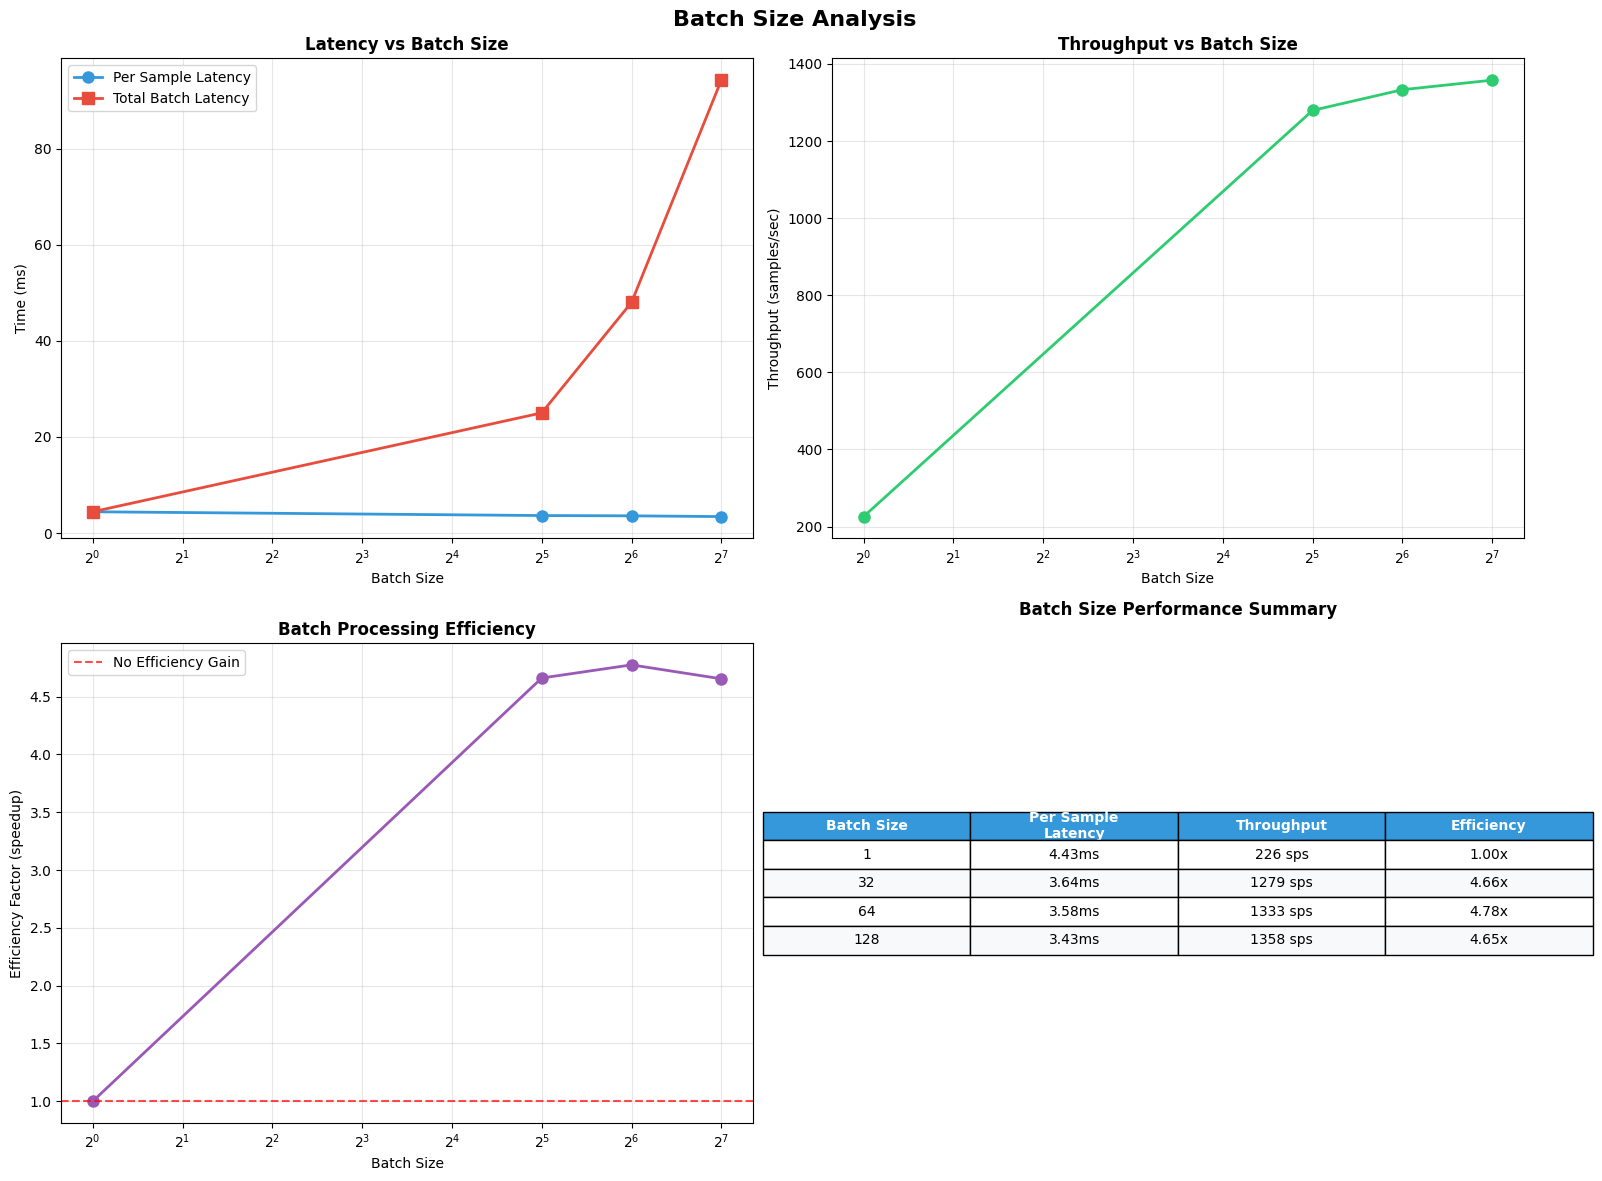


DEPLOYMENT OPTIMIZATION RESULTS:

   Mixed Precision (FP16):
     Tensor Core Eligible: 71.4%
     Estimated FLOP improvements: 29.0MB
     Estimated Speedup: 2.1x
     Estimated Throughput improvements %: 2.1%
     Estimated Memory Savings: 140.0MB

   Deployment Scenarios:
     Real Time Diagnosis:
       Optimal Batch Size: 128
       Use Case: Emergency diagnosis, single patient processing
     Batch Processing:
       Optimal Batch Size: 128
       Use Case: Screening workflows, research processing


In [75]:
# Run the complete deployment optimization analysis with all 2 implemented analysis functions above
def run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results):
    """
    Main function to run all deployment optimization analyses.
    """
    print("Running Deployment Optimization Analysis...")

    # Analyze mixed precision potential
    mixed_precision = analyze_mixed_precision_potential(detailed_results)
    mixed_precision_speedup = mixed_precision['estimated_speedup']
    
    # Analyze batch processing scenarios
    batch_results, batch_scenarios = analyze_batch_processing_scenarios(baseline_model, mixed_precision_speedup)

    # Visualize batch size analysis for deployment understanding
    plot_batch_size_comparison(batch_results)

    # Calculate deployment readiness
    current_latency = timing_results['single_sample_ms']
    current_throughput = timing_results['throughput_samples_per_sec']
    
    performance_metrics = {
        'latency_ms': current_latency,
        'throughput_samples_sec': current_throughput
    }
    
    return {
        'mixed_precision': mixed_precision,
        'batch_scenarios': batch_scenarios
    }

# Execute deployment analysis
deployment_analysis = run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results)

print(f"\nDEPLOYMENT OPTIMIZATION RESULTS:")
mp_details = deployment_analysis['mixed_precision']
print(f"\n   Mixed Precision (FP16):")
print(f"     Tensor Core Eligible: {mp_details['mixed_precision_coverage_percent']:.1f}%")
print(f"     Estimated FLOP improvements: {mp_details['avg_flop_reduction_percent']:.1f}MB")
print(f"     Estimated Speedup: {mp_details['estimated_speedup']:.1f}x")
print(f"     Estimated Throughput improvements %: {mp_details['throughput_improvement_percent']:.1f}%")
print(f"     Estimated Memory Savings: {mp_details['estimated_memory_reduction_mb']:.1f}MB")
#print(f"     Estimated Sensitivity Risk: {mp_details['sensitivity_risk']}")

if 'error' not in deployment_analysis['batch_scenarios']:
    scenarios = deployment_analysis['batch_scenarios']
    print(f"\n   Deployment Scenarios:")
    for scenario, details in scenarios.items():
        print(f"     {scenario.replace('_', ' ').title()}:")
        print(f"       Optimal Batch Size: {details['optimal_batch_size']}")
        print(f"       Use Case: {details['use_case']}")

> **_Before you move on...brainstorming time!_**
> 
> Based on your deployment analysis results above, collect your thoughts about hardware deployment opportunities - this will help you in completing your optimization plan at the end of the notebook:
>  
> 1. **Shared-Resource Constraints**: What is the main limiting factor when deploying the model alongside other applications—memory or compute?
Memory will be the main limiting factor as applications whether or not they are running will occupy memory. Compute will come into picture when you want to execute the model, however, prior to that model should be loaded into memory and if memory is limiting factor you wont even get to execution phase.

> 2. **Batch processing trade-offs**: How does performance change with batch size? What's the optimal configuration for different deployment scenarios?
As the batch size increases, throughput increases and latency decreases
For both scenarios batch size of 128 is optimal.
> 
> 3. **Mixed precision impact**: What percentage of operations can benefit from FP16? How much speedup can you realistically expect? What are the implementation risks?
71.4% operations can benefit from FP16
We can expect upto 2.1x speedup
When deploying to CPU based environment. FP16 might not work efficiently, so we may have either to revert it back to FP32 or quantize to 8 bit

> 
> 4. **Production Readiness Assessment**: Which KPI targets can be met with hardware acceleration alone?
batch throughput samples per second

## **Congratulations!** 

You have completed the model baseline analysis! This foundational work will guide all subsequent optimization efforts.

### **Summary: Key findings**
Document your analysis results using this framework:

1.  **Overall performance profile**: 

As we see except for sensitivity, baseline model performs poorly on all the benchmask statistics

As noted earlier, though nothing can be said with certainty as practical experiments many times defy theoretical calculations,  it appears that optimization targets can be met through combination of optimization techniques along with removal of convolutions blocks which do not add value.

2. **Bottlenecks**: 

Memory is the main bottleneck followed by compute. Peak memory usage is as high as 330mb. GFLOPs are 1.8+, latency is 3.5 ms. The interpolation factor in forward method is a big memory consumer. We should remove this as model is capable of handling all input sizes so long it can be reduced by half size at each of the five stages. So if we talk about 64 --> 32, 16, 8, 4 , 2 which looks good

3. **Architecture optimization**:

_- Top 2 architectural techniques with highest impact potential_<br> --> Interpolation and depthwise separable convolution

_- Implementation difficulty vs expected benefit analysis_<br> --> interpolation is easiest to implement followed by depthwise separable. Also parameter reduction, flop reduction and memory reduction is expected to be higher than inverted residual blocks

_- Estimated parameter reduction and optimization goals projections_<br>

Depthwise Separable:

     Candidate Layers: 16
     Avg Param Reduction Percent: 88.61099459358688
     Estimated Speedup: 54.49904057017544
     Avg Flop Reduction Percent: 90.83173428362574
     Estimated Memory Reduction Mb: 37.133544921875

   Inverted Residuals:

     Expansion Candidates: 8
     Avg Flop Reduction Percent: 90.16213814240018
     Avg Param Reduction Percent: 82.52331853105814
     Estimated Memory Reduction Mb: 34.46142578125

   Interpolation Removal:
   
     Current Input Size: 224
     Native Input Size: 64
     Avg Flop Reduction Percent: 0.9183673469387755


_- Other techniques you may consider beyond those listed>>_ 

We might want to remove convolution blocks that are not doing any value add. Also try to combine dense convolution blocks with optimized blocks

4. **Hardware deployment optimization**: 

_- Mixed precision acceleration potential and implementation plan_<br>

2.1x. We will do this when converting model to onnx format

_- Optimal batch configurations for different use cases_>>

128 for both


Mixed Precision (FP16):

     Tensor Core Eligible: 71.4%
     Estimated FLOP improvements: 29.0MB
     Estimated Speedup: 2.1x
     Estimated Throughput improvements %: 2.1%
     Estimated Memory Savings: 140.0MB

   Deployment Scenarios:
   
     Real Time Diagnosis:
       Optimal Batch Size: 128
       Use Case: Emergency diagnosis, single patient processing
     Batch Processing:
       Optimal Batch Size: 128
       Use Case: Screening workflows, research processing

### **Recommended optimization roadmap**

Based on the analysis, prioritize the optimization techniques and highlight the estimated combined impact on optimization goals for each phase:

**Phase 1 (Quick Wins):**

_<<TODO: List >=1 highest priority architectural recommendations>>_

interpolation, depthwise separable convolutions

_<<TODO: List >=1 highest priority hardware deployment recommendations>>_

Use hardware friendly architecture patterns and reduce the bitsize to FP16

**Phase 2 (Extra Impact):**

_<<TODO: List >=1 Additional architectural and hardware deployment recommendations>>_

We should implement inverted residual blocks. Also remove the convolution blocks that do not add value. Further experiment with combination of interpolation, depthwise separable, inverted residual blocks, dense convolution blocks and remove the convolution blocks that do not add value


---

**You are now ready to move to Notebook 2: Architecture Optimization!**